# Case 3 — Hydraulically Fractured Well
## POD Analysis: Linear Flow, Pseudo-Radial Transition, Reduced-Order Model


In [1]:
import numpy as np
import h5py, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import UnivariateSpline
from pathlib import Path
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import warnings
import matplotlib.ticker as ticker
from matplotlib.ticker import NullLocator

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})

C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
LF_C = '#6a0dad'   # purple — linear flow (Case 3 only)
GR   = '#555555'

PROJECT = Path('..')
DATA    = PROJECT/'data'/'01_synthetic'/'case3_fractured'
FIGS = PROJECT/'figures'
FIGS.mkdir(parents=True, exist_ok=True)
def sf(n): plt.savefig(FIGS/n,dpi=300,bbox_inches='tight'); print(f'  {n}')
print('Ready.')

Ready.


---
## 1 · Load Simulation Data

Non-uniform grid: `centroids_ft` locates the fracture column; well-cell sizes `dx_wc_ft`/`dy_wc_ft` come from `params.json` for the Peaceman correction.


In [2]:
with h5py.File(DATA/'snapshots_psia.mat','r') as f:
    _raw   = np.array(f['X_psia'])
    X_psia = _raw.T if _raw.shape[0]<_raw.shape[1] else _raw

with h5py.File(DATA/'well_data.mat','r') as f:
    bhp_raw = np.array(f['bhp_psia']).flatten()
    dp_raw  = np.array(f['delta_p_psi']).flatten()
    qr_raw  = np.array(f['rate_STBd']).flatten()
    t_raw   = np.array(f['time_hr']).flatten()

with h5py.File(DATA/'rock_field.mat','r') as f:
    perm_mD = np.array(f['perm_mD']).flatten()

# centroids [n_cells x 2] in ft — needed for fracture location and Peaceman
with h5py.File(DATA/'grid_field.mat','r') as f:
    _c = np.array(f['centroids_ft'])
    centroids_ft = _c.T if _c.shape[0]==2 else _c

with h5py.File(DATA/'frac_cells.mat','r') as f:
    frac_cells_py = np.array(f['frac_cells']).flatten().astype(int) - 1

with open(DATA/'params.json') as f:
    P = json.load(f)

n_t     = min(len(t_raw), X_psia.shape[1])
t_raw   = t_raw[:n_t];  bhp_raw = bhp_raw[:n_t]
dp_raw  = dp_raw[:n_t]; qr_raw  = qr_raw[:n_t]
X_psia  = X_psia[:,:n_t]

pi_   = P['p_init_psia']
valid = (t_raw>0)&(dp_raw>0)&(dp_raw<pi_)&(bhp_raw>0)&(bhp_raw<=pi_)
t   = t_raw[valid];  dp  = dp_raw[valid]
bhp = bhp_raw[valid]; qr  = qr_raw[valid]
X   = X_psia[:,valid]

N, m  = X.shape
nx    = int(P['nx'])          # 101
ny    = int(P['ny'])          # 120
wc    = int(P['well_cell_matlab']) - 1
t_wbs = P['t_wbs_end_hr']
t_psr = P['t_psr_start_hr']  # LF end / PSR onset
t_pss = P['t_pss_start_hr']  # BDF onset

m_wbs = t < t_wbs
m_lf  = (t >= t_wbs) & (t < t_psr)
m_psr = (t >= t_psr) & (t < t_pss)
m_bdf = t >= t_pss

# Fracture column: find by x-centroid closest to Lx/2
# centroids[:,0] = x-coordinates; reshape to (ny,nx) row=y, col=x
Lx_ft = P['Lx_ft'];  Ly_ft = P['Ly_ft']
x_row = centroids_ft[:nx, 0]          # x-coords of first y-row
frac_col_py = int(np.argmin(np.abs(x_row - Lx_ft/2)))

# Fracture row range (for visualisation)
frac_row_min = int(frac_cells_py.min() // nx)
frac_row_max = int(frac_cells_py.max() // nx)

xf_ft = P['xf_ft'];  xf_m = P['xf_m']
k_m   = P['k_matrix_mD'];  k_f = P['k_fracture_mD']

print(f'Snapshot matrix  X : {X.shape}')
print(f'Grid               : {nx}x{ny} = {nx*ny} cells (non-uniform x)')
print(f'Domain             : {Lx_ft/3.281:.0f}x{Ly_ft/3.281:.0f} m')
print(f'Time range         : {t[0]:.5f} – {t[-1]:.0f} hr')
print(f'BHP range          : {bhp.min():.1f} – {bhp.max():.1f} psia')
print(f't_WBS={t_wbs:.3f}  t_PSR={t_psr:.0f}  t_BDF={t_pss:.0f} hr')
print(f'WBS({m_wbs.sum()})  LF({m_lf.sum()})  PSR({m_psr.sum()})  BDF({m_bdf.sum()})')
print(f'Fracture col (py)  : {frac_col_py}  rows {frac_row_min}–{frac_row_max}')
print(f'xf={xf_m:.0f}m={xf_ft:.0f}ft  k_m={k_m:.0f}mD  k_f={k_f:.0f}mD')

Snapshot matrix  X : (12120, 400)
Grid               : 101x120 = 12120 cells (non-uniform x)
Domain             : 6000x6000 m
Time range         : 0.00100 – 50000 hr
BHP range          : 4050.7 – 4500.5 psia
t_WBS=0.816  t_PSR=1428  t_BDF=19018 hr
WBS(151)  LF(168)  PSR(59)  BDF(22)
Fracture col (py)  : 50  rows 52–67
xf=400m=1312ft  k_m=5mD  k_f=100000mD


---
## 2 · Fracture Geometry Visualisation

Binary permeability field (matrix vs. fracture); `aspect='auto'` throughout (non-square cells).


---
## 3 · PTA Diagnostics

Linear-flow reference:

$$\Delta p(t) = m_{LF}\sqrt{t}, \qquad m_{LF} = \frac{4.064\,q\,B_o\,\mu}{x_f h\sqrt{k_m\phi\mu c_t}}$$

Bourdet slope 1/2 during LF; flattens to $\Delta p'_{PSR}=70.6\,q\mu B_o/(k_m h)$ at PSR onset.


In [3]:
k    = P['k_matrix_mD']; phi_ = P['phi'];   ct  = P['ct_psi1'];  mu  = P['mu_cp']
rw   = P['rw_ft'];        kh   = P['kh_mDft']; q = P['q_STBd'];  Bo  = P['Bo']
pi_  = P['p_init_psia'];  h_ft = P['h_ft']
dp_flat_psr = P['dp_prime_psi']
m_LF_theory = P['m_LF_psi_hr05']

def bourdet(dp_arr, t_arr, L=0.2):
    n,lnt,d = len(dp_arr),np.log(t_arr),np.zeros(len(dp_arr))
    for i in range(1,n-1):
        jl=i-1
        while jl>0   and lnt[i]-lnt[jl]<L: jl-=1
        jr=i+1
        while jr<n-1 and lnt[jr]-lnt[i]<L: jr+=1
        dL,dR = lnt[i]-lnt[jl], lnt[jr]-lnt[i]
        if dL>0 and dR>0:
            d[i]=((dp_arr[i]-dp_arr[jl])/dL*dR+(dp_arr[jr]-dp_arr[i])/dR*dL)/(dL+dR)
        elif dL>0: d[i]=(dp_arr[i]-dp_arr[jl])/dL
        elif dR>0: d[i]=(dp_arr[jr]-dp_arr[i])/dR
    d[0]=(dp_arr[1]-dp_arr[0])/(lnt[1]-lnt[0])
    d[-1]=(dp_arr[-1]-dp_arr[-2])/(lnt[-1]-lnt[-2])
    return d

dpr = bourdet(dp, t)
vs  = (dpr>1e-2)&(dp>1e-2)

cf_lf    = np.polyfit(np.sqrt(t[m_lf]), dp[m_lf], 1)
m_LF_sim = cf_lf[0]
xf_est   = 4.064*q*Bo*mu / (m_LF_sim*h_ft*np.sqrt(k*phi_*mu*ct))

flat_psr_sim = np.median(dpr[m_psr&vs]) if m_psr.any() else np.nan
kh_psr_est   = 70.6*q*mu*Bo/flat_psr_sim if np.isfinite(flat_psr_sim) else np.nan

m_LF_ref     = m_LF_sim       
flat_psr_ref = flat_psr_sim 

print(f'LF slope  m_LF      : {m_LF_sim:.4f} psi/hr^0.5  (theory {m_LF_theory:.4f})')
print(f'xf  estimate        : {xf_est:.0f} ft  (true {xf_ft:.0f} ft)')
print(f'Bourdet flat (PSR)  : {flat_psr_sim:.4f} psi  (theory {dp_flat_psr:.4f})')
print(f'kh_m estimate (PSR) : {kh_psr_est:.1f} mD-ft  (true {kh:.1f})')

LF slope  m_LF      : 3.5817 psi/hr^0.5  (theory 6.3320)
xf  estimate        : 2320 ft  (true 1312 ft)
Bourdet flat (PSR)  : 86.4931 psi  (theory 103.9232)
kh_m estimate (PSR) : 901.1 mD-ft  (true 750.0)


### Figure 2 — $p_{wf}$ vs Log $t$


### Figure 3 — Bourdet Derivative


### Figure 4 — Combined Diagnostic


  ch4_4_pwf_pd_case3.pdf


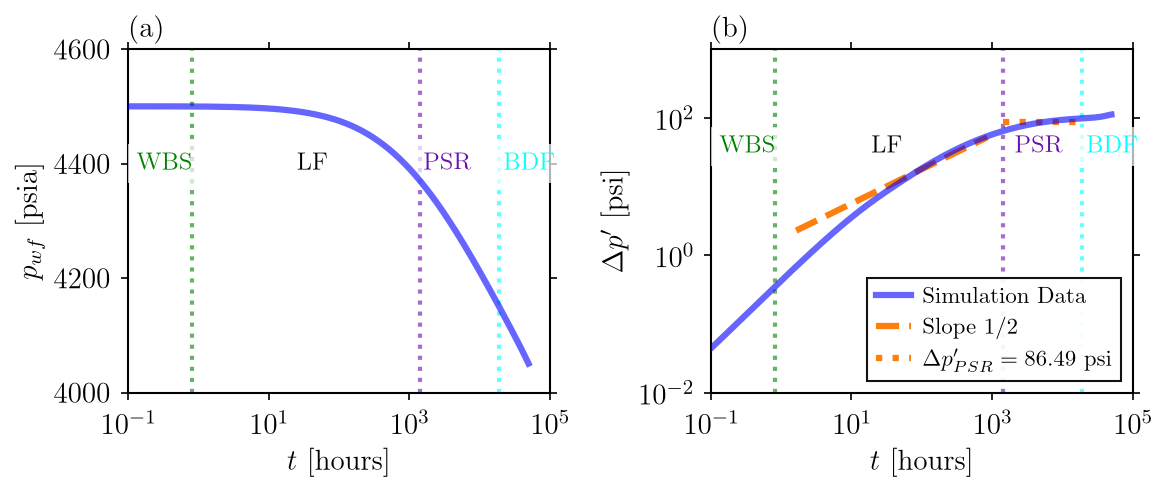

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# --- Plot (a): Semilog Plot ---
ax = axes[0]
ax.semilogx(t, bhp, color='b', alpha=0.6, lw=3.0, label='Simulation Data', zorder=4)

t_lf_line = np.linspace(t[m_lf][0], t[m_lf][-1], 300)
#ax.semilogx(t_lf_line, pi_ - m_LF_ref * np.sqrt(t_lf_line),
#            '--', color='C1', lw=2, label='Ref. Solution')

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)
ax.axvline(t_psr, color=LF_C,    lw=2, ls=':', alpha=0.6)
ax.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.6)

#ax.axvspan(0.1,   t_wbs, color='C3', alpha=0.1)
#ax.axvspan(t_wbs, t_psr, color='C1', alpha=0.08)
#ax.axvspan(t_psr, t_pss, color='C2', alpha=0.08)
#ax.axvspan(t_pss, 1e5,   color='C4', alpha=0.1)

ax.text(0.02, 0.70, 'WBS', transform=ax.transAxes, fontsize=12, color='green',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.40, 0.70, 'LF', transform=ax.transAxes, fontsize=12, color='black',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.70, 0.70, 'PSR', transform=ax.transAxes, fontsize=12, color=LF_C,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.89, 0.70, 'BDF', transform=ax.transAxes, fontsize=12, color='cyan',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([0.1, 1e5])
ax.set_ylim([4000, 4600])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
#ax.legend(loc='upper right', framealpha=0.93, fontsize=10)

# --- Plot (b): Bourdet Derivative ---
ax = axes[1]
#ax.axvspan(0.1,   t_wbs, color='C3', alpha=0.1)
#ax.axvspan(t_wbs, t_psr, color='C1', alpha=0.08)
#ax.axvspan(t_psr, t_pss, color='C2', alpha=0.08)
#ax.axvspan(t_pss, 1e5,   color='C4', alpha=0.1)

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)
ax.axvline(t_psr, color=LF_C,    lw=2, ls=':', alpha=0.6)
ax.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.6)

ax.loglog(t[vs], dpr[vs], color='b', alpha=0.6, lw=3.0, label='Simulation Data', zorder=4)

t_ref = np.logspace(np.log10(t_wbs*2), np.log10(t_psr*0.6), 100)
ax.loglog(t_ref, (m_LF_ref/2) * np.sqrt(t_ref),
          '--', color='C1', lw=3, label='Slope 1/2')
ax.loglog([t_psr, t_pss], [flat_psr_ref, flat_psr_ref],
          ':', color='C1', lw=3,
          label=rf"$\Delta p'_{{PSR}}={flat_psr_ref:.2f}$ psi")

ax.text(0.02, 0.75, 'WBS', transform=ax.transAxes, fontsize=12, color='green',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.38, 0.75, 'LF', transform=ax.transAxes, fontsize=12, color='black',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.72, 0.75, 'PSR', transform=ax.transAxes, fontsize=12, color=LF_C,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.89, 0.75, 'BDF', transform=ax.transAxes, fontsize=12, color='cyan',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(b)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel(r"$\Delta p'$ [psi]")
ax.set_xlim([0.1, 1e5])
ax.set_ylim([0.01, 1e3])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
ax.legend(loc='lower right', framealpha=0.93, edgecolor='k', fontsize=11)

plt.tight_layout()
#sf('fig4_fract_pwf_dpp.pdf')
sf('ch4_4_pwf_pd_case3.pdf')
plt.show()

---
## 4 · Linear Flow Diagnostic: $\Delta p$ vs $\sqrt{t}$

$$x_f\sqrt{k_m} = \frac{4.064\,q\,B_o\,\mu}{m_{LF}\,h\,\sqrt{\phi\mu c_t}}$$


---
## 5 · Pressure Field Visualisation

Elliptical LF depletion (elongated along $x$) transitions to near-circular at PSR.


  ch4_9_p_field_case3.pdf


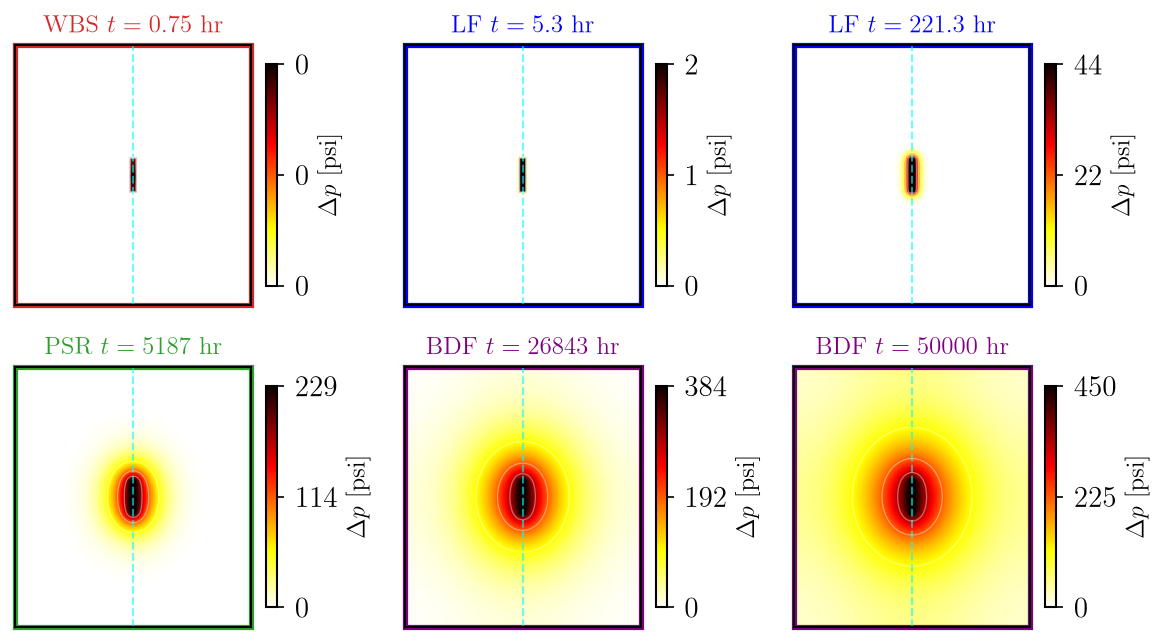

In [5]:
dX = P['p_init_psia'] - X
def snap_idx(tv): return int(np.argmin(np.abs(t-tv)))

snaps = [
    (snap_idx(t[m_wbs][-2]),
     f'WBS  $t={t[m_wbs][-2]:.2f}$ hr', 'C3'),
    (snap_idx(t[m_lf][len(t[m_lf])//4]),
     f'LF  $t={t[m_lf][len(t[m_lf])//4]:.1f}$ hr', 'blue'),
    (snap_idx(t[m_lf][3*len(t[m_lf])//4]),
     f'LF  $t={t[m_lf][3*len(t[m_lf])//4]:.1f}$ hr', 'blue'),
    (snap_idx(t[m_psr][len(t[m_psr])//2]),
     f'PSR  $t={t[m_psr][len(t[m_psr])//2]:.0f}$ hr', 'C2'),
    (snap_idx(t[m_bdf][len(t[m_bdf])//3]),
     f'BDF  $t={t[m_bdf][len(t[m_bdf])//3]:.0f}$ hr', 'purple'),
    (snap_idx(t[m_bdf][-1]),
     f'BDF  $t={t[m_bdf][-1]:.0f}$ hr', 'purple'),
]

fig, axes = plt.subplots(2,3,figsize=(8,4.5))
for ax,(ki,ttl,col) in zip(axes.flat, snaps):
    F  = dX[:,ki].reshape(ny,nx)
    vm = max(F.max(),0.1)
    im = ax.imshow(F,origin='lower',cmap='hot_r',
                   vmin=0,vmax=vm,aspect='auto')
    ax.axvline(frac_col_py,color='cyan',lw=1.0,ls='--',alpha=0.6)
    #ax.plot(frac_col_py,ny//2-0.5,'o',color='white',ms=4,mew=2.5,zorder=10)
    for lp in [0.25,0.50,0.75]:
        lv=vm*lp
        if lv>0.05:
            ax.contour(F,levels=[lv],colors=['w'],linewidths=0.6,alpha=0.4)
    ax.set_title(ttl,fontsize=12,color=col,fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.add_patch(plt.Rectangle((0,0),1,1,fill=False,ec=col,lw=2.5,
                               transform=ax.transAxes,clip_on=False))
    cb=plt.colorbar(im,ax=ax,shrink=0.85)
    cb.set_ticks([0,vm/2,vm])
    cb.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    cb.set_label(r'$\Delta p$ [psi]',fontsize=12)
    #ax.text(0.97,0.03,f'max={vm:.0f} psi',
           # transform=ax.transAxes,fontsize=8.5,ha='right',va='bottom',
           # color='white',family='monospace',
           # bbox=dict(fc='k',alpha=0.6,pad=1.5,ec='none'))
plt.tight_layout()
sf('ch4_9_p_field_case3.pdf')
plt.show()

---
## 6 · Proper Orthogonal Decomposition (POD)

$\mathbf{X}_c=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$; non-uniform grid does not affect the POD mathematics.


In [6]:
X_mean = X.mean(axis=1,keepdims=True)
Xc     = X - X_mean
U, sv, Vt = np.linalg.svd(Xc, full_matrices=False)

sn  = sv/sv[0]
cum = np.cumsum(sv**2)/np.sum(sv**2)*100

r99  = int(np.searchsorted(cum,99.0))+1
r999 = int(np.searchsorted(cum,99.9))+1
r_sel = max(r999,2)

print(f'Snapshot matrix      : {X.shape}')
print(f'σ₁                   : {sv[0]:.2f} psia')
print(f'σ₂/σ₁                : {sn[1]:.3e}  (spectral gap)')
print(f'r for 99.0%% energy  : {r99}')
print(f'r for 99.9%% energy  : {r999}  ← selected r = {r_sel}')
for i in range(min(6,len(sv))):
    print(f'  Mode {i+1}  σ={sv[i]:.2f}  σᵢ/σ₁={sn[i]:.2e}  cumE={cum[i]:.4f}%')

Snapshot matrix      : (12120, 400)
σ₁                   : 48681.47 psia
σ₂/σ₁                : 2.329e-01  (spectral gap)
r for 99.0%% energy  : 2
r for 99.9%% energy  : 3  ← selected r = 3
  Mode 1  σ=48681.47  σᵢ/σ₁=1.00e+00  cumE=94.2370%
  Mode 2  σ=11339.20  σᵢ/σ₁=2.33e-01  cumE=99.3498%
  Mode 3  σ=3750.53  σᵢ/σ₁=7.70e-02  cumE=99.9092%
  Mode 4  σ=1384.52  σᵢ/σ₁=2.84e-02  cumE=99.9854%
  Mode 5  σ=543.23  σᵢ/σ₁=1.12e-02  cumE=99.9971%
  Mode 6  σ=234.68  σᵢ/σ₁=4.82e-03  cumE=99.9993%


### Figure 7 — Singular Value Spectrum


<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
C:\Users\Acer\AppData\Local\Temp\ipykernel_17600\2974672091.py:23: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_xlabel('$r$'); ax2.set_ylabel('$E_r$ [\%]')


  ch5_9_svd_rank_case3.pdf


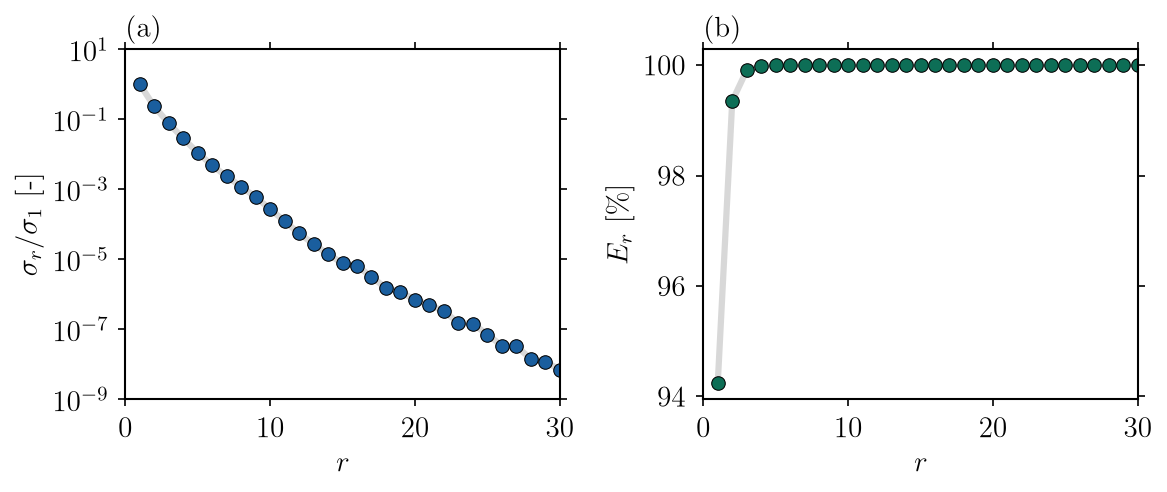

In [7]:
fig, axes = plt.subplots(1,2,figsize=(8,3.5))

ax=axes[0]
ax.semilogy(range(1,31),sn[:30],'o',color=C1,ms=6.5,mec='k',mew=0.5)
ax.semilogy(range(1,31),sn[:30],color='gray',alpha=0.3,lw=3,zorder=1)
ax.set_title('(a)',loc='left',fontweight='normal')
ax.set_xlabel('$r$'); ax.set_ylabel(r'$\sigma_r/\sigma_1$ [-]')
ax.set_xlim([0,30]); ax.set_ylim(1e-9,10)
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

#for idx,col in [(0,'C3'),(1,'C0'),(2,'C5'),(3,'C8')]:
    #ax.axvline(idx+1,color=col,ls=':',lw=1.5)
    #ax.text(idx+1,sn[min(idx,len(sn)-1)]*0.2,
            #f'$i={idx+1}$',color=col,rotation=90,
           # ha='right',va='center',fontweight='bold',
           # bbox=dict(facecolor='white',edgecolor='none',alpha=0.8,pad=1))

ax2=axes[1]
ax2.plot(range(1,31),cum[:30],'o',color=C2,ms=6.5,mec='k',mew=0.5)
ax2.plot(range(1,31),cum[:30],color='gray',alpha=0.3,lw=3,zorder=1)
ax2.set_title('(b)',loc='left',fontweight='normal')
ax2.set_xlabel('$r$'); ax2.set_ylabel('$E_r$ [\%]')
ax2.set_xlim([0,30])
x_positions=[22,8,22,8]; va_positions=['top','bottom','top','bottom']
#for ii,(idx,col) in enumerate([(0,'C3'),(1,'C0'),(2,'C5'),(3,'C8')]):
    #if idx<len(cum):
        #ax2.axhline(cum[idx],color=col,ls=':',lw=1.5)
        #ax2.text(x_positions[ii],cum[idx],
                # f'$r={idx+1}\\ (E_r={cum[idx]:.2f}\\%)$',
                 #color=col,ha='center',va=va_positions[ii],fontweight='bold',
                # bbox=dict(facecolor='white',edgecolor='none',alpha=0.8,pad=1))
plt.tight_layout()
#sf('fig7_svd_spectrum.pdf')
sf('ch5_9_svd_rank_case3.pdf')
plt.show()

### Figure 8 — POD Spatial Modes and Temporal Coefficients


---
## 7 · Singular Spectrum Analysis (SSA)


  ch5_10_pod_modes_case3.pdf


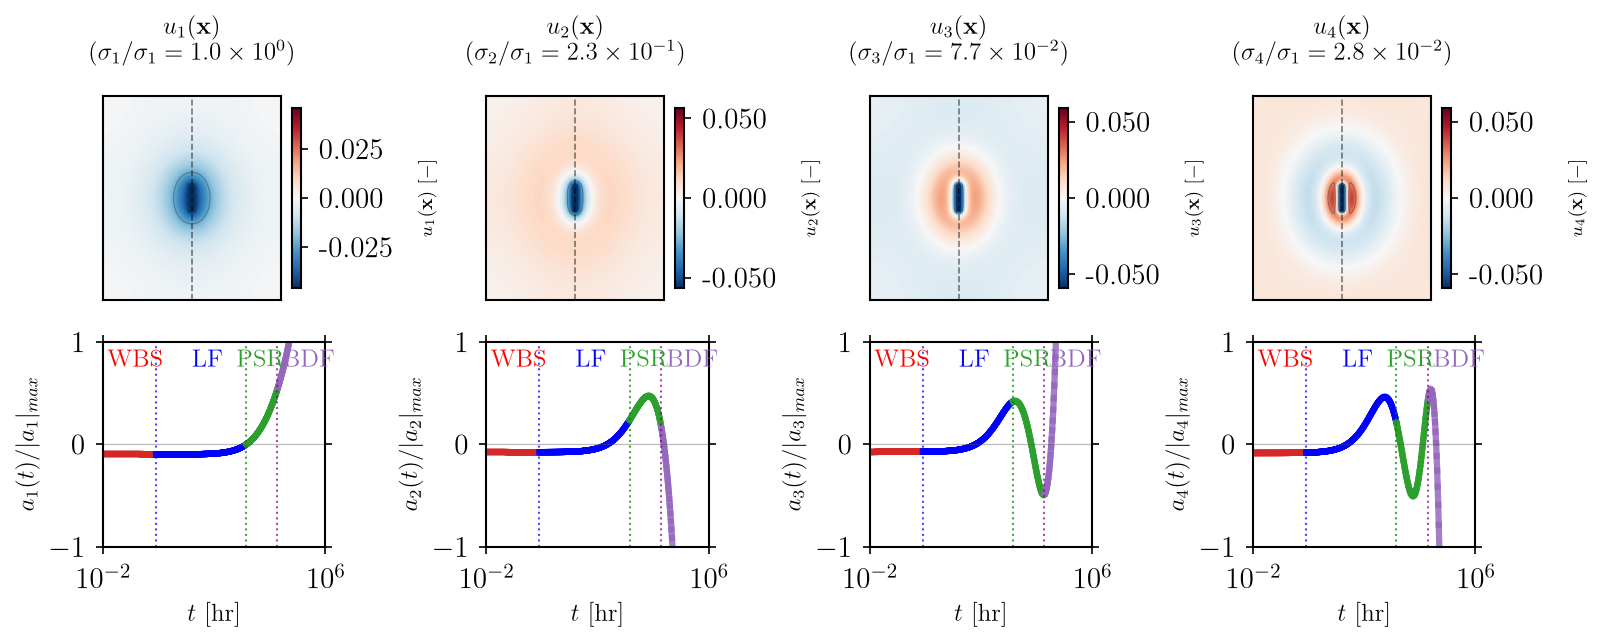

In [8]:
n_show=4
fig, axes = plt.subplots(2,n_show,figsize=(11,4.5))
if n_show==1: axes=axes.reshape(2,1)

mode_phys=['Fracture depletion\n(dominant linear)',
           'LF to PSR\ntransition',
           'Near-fracture\ngradient',
           'Higher-order\ncorrection']

for i in range(n_show):
    ax=axes[0,i]
    ui=U[:,i].reshape(ny,nx)
    vm=np.abs(ui).max()
    im=ax.imshow(ui,origin='lower',cmap='RdBu_r',
                 vmin=-vm,vmax=vm,aspect='auto')
    m_val=f'{sn[i]:.1e}'.split('e')[0]
    e_val=int(f'{sn[i]:.1e}'.split('e')[1])
    ax.axvline(frac_col_py,color='k',lw=0.8,ls='--',alpha=0.5)
    #ax.plot(frac_col_py,ny//2,'k+',ms=10,mew=2.5,zorder=10)
    ax.contour(np.abs(ui),levels=[vm*0.5],colors=['k'],
               linewidths=0.4,alpha=0.35)
    ax.set_title(
        f'${{u}}_{{{i+1}}}(\\mathbf{{x}})$\n'
        f'$(\\sigma_{{{i+1}}}/\\sigma_1={m_val}\\times10^{{{e_val}}})$\n',fontsize=12)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.colorbar(im,ax=ax,shrink=0.88,format='%.3f').set_label(
        rf'$u_{i+1}(\mathbf{{x}})\ [-]$',
        fontsize=9,rotation=90,labelpad=12)

    ax2=axes[1,i]
    ai=sv[i]*Vt[i,:]; ai_n=ai/np.abs(ai).max()
    col_seg=[('C3' if ti<t_wbs else 'blue' if ti<t_psr
              else 'C2' if ti<t_pss else 'C4') for ti in t]
    for j in range(len(t)-1):
        ax2.semilogx(t[j:j+2],ai_n[j:j+2],
                     color=col_seg[j],lw=3,alpha=0.85)
    ax2.axvline(t_wbs,color='blue',lw=1.0,ls=':',alpha=0.7)
    ax2.axvline(t_psr,color='green',  lw=1.0,ls=':',alpha=0.7)
    ax2.axvline(t_pss,color='purple', lw=1.0,ls=':',alpha=0.7)
    ax2.axhline(0,color=GR,lw=0.6,alpha=0.4)
    ax2.set_xlabel('$t$ [hr]',fontsize=12)
    ax2.set_ylabel(f'$a_{i+1}(t)/|a_{i+1}|_{{max}}$',fontsize=12)
    ax2.set_xlim([0.01,1e6]); 
    ax2.set_ylim([-1,1])
    ax2.text(0.02,0.88,'WBS',transform=ax2.transAxes,
             color='red',fontweight='normal',fontsize=12)
    ax2.text(0.4,0.88,'LF',transform=ax2.transAxes,
             color='blue',fontweight='normal',fontsize=12)
    ax2.text(0.6,0.88,'PSR',transform=ax2.transAxes,
             color='C2',fontweight='normal',fontsize=12)
    ax2.text(0.81,0.88,'BDF',transform=ax2.transAxes,
             color='C4',fontweight='normal',fontsize=12)
plt.tight_layout()
#sf('fig8_fract_pod_modes_temporal.pdf')
sf('ch5_10_pod_modes_case3.pdf')
plt.show()

  ch6_3_ssa_case3.pdf


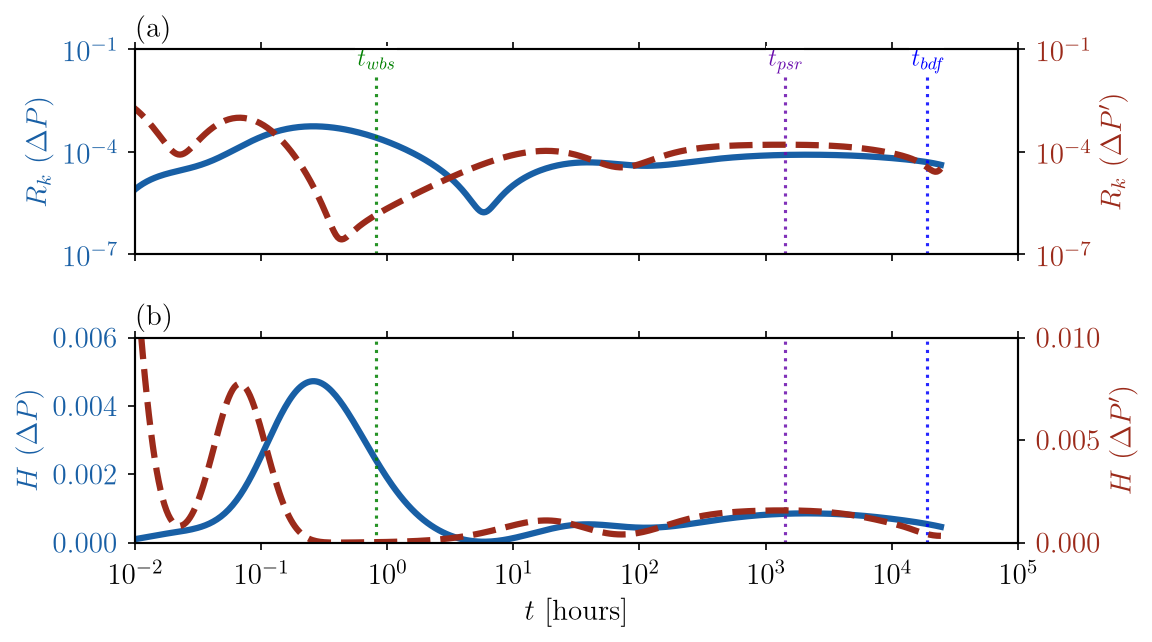

In [9]:
dp_bhp   = P['p_init_psia'] - bhp
tau      = np.log(t)
tau_uni  = np.linspace(tau.min(), tau.max(), 500)
t_uni    = np.exp(tau_uni)

f_interp = interp1d(tau, dp_bhp, kind='cubic')
dp_uni   = f_interp(tau_uni)
dpr_uni  = np.gradient(dp_uni, tau_uni)

# =============================================================================
# SECTION 2: HANKEL EMBEDDING — built for both signals
# =============================================================================
def _build_hankel(signal, d):
    n = len(signal)
    M = n - d + 1
    H = np.zeros((d, M))
    for i in range(d):
        H[i, :] = signal[i : i + M]
    return H

d_h    = 25
W_h    = 40
k_rank = 3

H_dp  = _build_hankel(dp_uni,  d_h)   # from ΔP
H_dpr = _build_hankel(dpr_uni, d_h)   # from ΔP'

m_Hank = H_dp.shape[1]                # K' - d_h + 1
t_Hank = t_uni[d_h - 1:]                  # exactly m_Hank entries

# =============================================================================
# SECTION 3: SLIDING SSA — runs for both Hankel matrices
# =============================================================================
def _sliding_ssa(H_mat, t_Hank, W_h, k_rank):
    m      = H_mat.shape[1]
    n_h    = m - W_h
    t_str  = np.zeros(n_h)
    Rk     = np.zeros(n_h)
    H_ent  = np.zeros(n_h)

    for k_s in range(n_h):
        Xw          = H_mat[:, k_s : k_s + W_h]
        t_str[k_s]  = t_Hank[k_s + W_h // 2]

        try:
            _, S_w, _       = np.linalg.svd(Xw, full_matrices=False)
            energies        = S_w ** 2
            E_primary       = energies[0]

            Rk[k_s]         = np.sum(energies[1:k_rank]) / E_primary

            e_trunc         = energies[energies > 1e-10 * E_primary]
            p_i             = e_trunc / e_trunc.sum()
            H_ent[k_s]      = -np.sum(p_i * np.log(p_i))

        except Exception:
            Rk[k_s]    = np.nan
            H_ent[k_s] = np.nan

    return t_str, Rk, H_ent

t_stream_dp,  Rk_dp,  H_dp_ent  = _sliding_ssa(H_dp,  t_Hank, W_h, k_rank)
t_stream_dpr, Rk_dpr, H_dpr_ent = _sliding_ssa(H_dpr, t_Hank, W_h, k_rank)

# =============================================================================
# SECTION 4: SMOOTHING
# =============================================================================
def _smooth(arr):
    valid = np.isfinite(arr)
    n     = valid.sum()
    win   = 31 if n > 31 else (n // 2) * 2 - 1
    out   = np.full(len(arr), np.nan)
    out[valid] = savgol_filter(arr[valid], window_length=win, polyorder=3)
    return out, valid

H_dp_smooth,  v_dp  = _smooth(H_dp_ent)
H_dpr_smooth, v_dpr = _smooth(H_dpr_ent)

# valid masks for Rk (raw, no smoothing)
vr_dp  = np.isfinite(Rk_dp)
vr_dpr = np.isfinite(Rk_dpr)

# Stable radial flow: minimum Rk for each signal
idx_dp  = np.argmin(Rk_dp[vr_dp])
idx_dpr = np.argmin(Rk_dpr[vr_dpr])
t_stable_dp  = t_stream_dp[vr_dp][idx_dp]
t_stable_dpr = t_stream_dpr[vr_dpr][idx_dpr]

# =============================================================================
# SECTION 5: PLOTTING
# =============================================================================
# Color palette
C_dp  = '#185FA5'   # blue  — ΔP
C_dpr = '#9b2a1a'   # red   — ΔP'

# Added the t_psr (Pseudo-Steady Radial) regime boundary for Case 3
ref_events = [(t_wbs, 'green', r'$t_{wbs}$'),
              (t_psr, LF_C,    r'$t_{psr}$'),
              (t_pss, 'blue',  r'$t_{bdf}$')]

# Applied standard figsize
fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.08)

# --- (a) Multi-Rank Complexity Rk — twin y axes ---
ax1      = axes[0]
ax1_twin = ax1.twinx()

ax1.loglog     (t_stream_dp[vr_dp],   Rk_dp[vr_dp],   color=C_dp,  lw=3.0, label=r'$R_k$ ($\Delta P$)')
ax1_twin.loglog(t_stream_dpr[vr_dpr], Rk_dpr[vr_dpr], color=C_dpr, lw=3.0, label=r"$R_k$ ($\Delta P'$)", ls='--')

# t_stable markers
#ax1.scatter     (t_stable_dp,  Rk_dp[vr_dp][idx_dp],   color=C_dp,  s=60, zorder=5, marker='v')
#ax1_twin.scatter(t_stable_dpr, Rk_dpr[vr_dpr][idx_dpr], color=C_dpr, s=60, zorder=5, marker='v')

ax1.set_ylabel     (r'$R_k$  ($\Delta P$)',  color=C_dp)
ax1_twin.set_ylabel(r"$R_k$  ($\Delta P'$)", color=C_dpr)
ax1.tick_params(axis='y', labelcolor=C_dp)
ax1_twin.tick_params(axis='y', labelcolor=C_dpr)
ax1.set_ylim([1e-7, 1e-1])
ax1_twin.set_ylim([1e-7, 1e-1])
ax1.set_title('(a)', loc='left')

ax1.xaxis.set_minor_locator(NullLocator())
ax1.yaxis.set_minor_locator(NullLocator())
ax1_twin.yaxis.set_minor_locator(NullLocator())

# combined legend
lines  = ax1.get_lines()      + ax1_twin.get_lines()
labels = [l.get_label() for l in lines]
#ax1.legend(lines, labels, fontsize=12, framealpha=0.9, loc='upper left')

# --- (b) Spectral Entropy H — twin y axes ---
ax2      = axes[1]
ax2_twin = ax2.twinx()

ax2.semilogx     (t_stream_dp[v_dp],   H_dp_smooth[v_dp],   color=C_dp,  lw=3.0, label=r'$H$ ($\Delta P$)')
ax2_twin.semilogx(t_stream_dpr[v_dpr], H_dpr_smooth[v_dpr], color=C_dpr, lw=3.0, label=r"$H$ ($\Delta P'$)", ls='--')

ax2.set_ylabel     (r'$H$  ($\Delta P$)',  color=C_dp)
ax2_twin.set_ylabel(r"$H$  ($\Delta P'$)", color=C_dpr)
ax2.tick_params(axis='y', labelcolor=C_dp)
ax2_twin.tick_params(axis='y', labelcolor=C_dpr)
ax2.tick_params(axis='x')
ax2.set_xlabel(r'$t$  [hours]')
ax2.set_title('(b)', loc='left')
ax2.set_ylim([0, 0.006])
ax2_twin.set_ylim([0, 0.01])

ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())
ax2_twin.yaxis.set_minor_locator(NullLocator())

lines2  = ax2.get_lines()      + ax2_twin.get_lines()
labels2 = [l.get_label() for l in lines2]
#ax2.legend(lines2, labels2, fontsize=12, framealpha=0.9, loc='upper left')

# --- shared decorations ---
for ax_s in [ax1, ax2]:
    for tv, col, _ in ref_events:
        ax_s.axvline(tv, color=col, lw=1.5, ls=':', alpha=0.85)

for tv, col, lbl in ref_events:
    ax1.text(tv, 0.92, lbl,
             transform  = ax1.get_xaxis_transform(),
             fontsize=12, ha='center', color=col, fontweight='normal',
             bbox=dict(facecolor='white', edgecolor='none', pad=1.0))

# Extended x-limit to 100,000 to fit Case 3 boundaries
ax1.set_xlim([0.01, 1e5])

plt.tight_layout()
sf('ch6_3_ssa_case3.pdf')
plt.show()

---
## 8 · POD-Based Reconstruction

Peaceman correction (finest, near-fracture cell); negligible here ($k_f=100{,}000$ mD) but retained for consistency with Cases 1–2.


In [10]:
# Peaceman correction — use well-cell dimensions from params.json
# For non-uniform grid dx_wc_ft is the x-width of the centre (finest) cell
dx_wc_ft = P['dx_wc_ft']
dy_wc_ft = P['dy_wc_ft']
r_eq_ft  = np.sqrt(0.14**2 * dx_wc_ft**2 + 0.14**2 * dy_wc_ft**2)
kh_well_cell = P['k_well_cell_mD'] * P['h_ft']
dp_correction = (141.2*P['q_STBd']*P['mu_cp']*P['Bo']/kh_well_cell
                 * np.log(r_eq_ft/P['rw_ft']))

X_rom = U[:,:r_sel]@np.diag(sv[:r_sel])@Vt[:r_sel,:]+X_mean
eps_t = np.linalg.norm(X-X_rom,axis=0)/np.linalg.norm(X,axis=0)*100
eps_g = np.linalg.norm(X-X_rom,'fro')/np.linalg.norm(X,'fro')*100

print(f'Well-cell dx_wc = {dx_wc_ft:.4f} ft  dy_wc = {dy_wc_ft:.4f} ft')
print(f'k_well_cell     = {P["k_well_cell_mD"]:.0f} mD  (fracture)')
print(f'dp_correction   = {dp_correction:.4f} psia  (negligible)')
print(f'POD rank r      = {r_sel}')
print(f'Global ε_G      = {eps_g:.4f}%')
print(f'Max step error  = {eps_t.max():.4f}%')

Well-cell dx_wc = 389.8028 ft  dy_wc = 164.0420 ft
k_well_cell     = 100000 mD  (fracture)
dp_correction   = 0.0533 psia  (negligible)
ROM rank r      = 3
Global ε_G      = 0.0153%
Max step error  = 0.0672%


### Figure 11 — POD vs Simulator: BHP and Bourdet Derivative


  ch5_11_pwf_dp_recon_case3.pdf


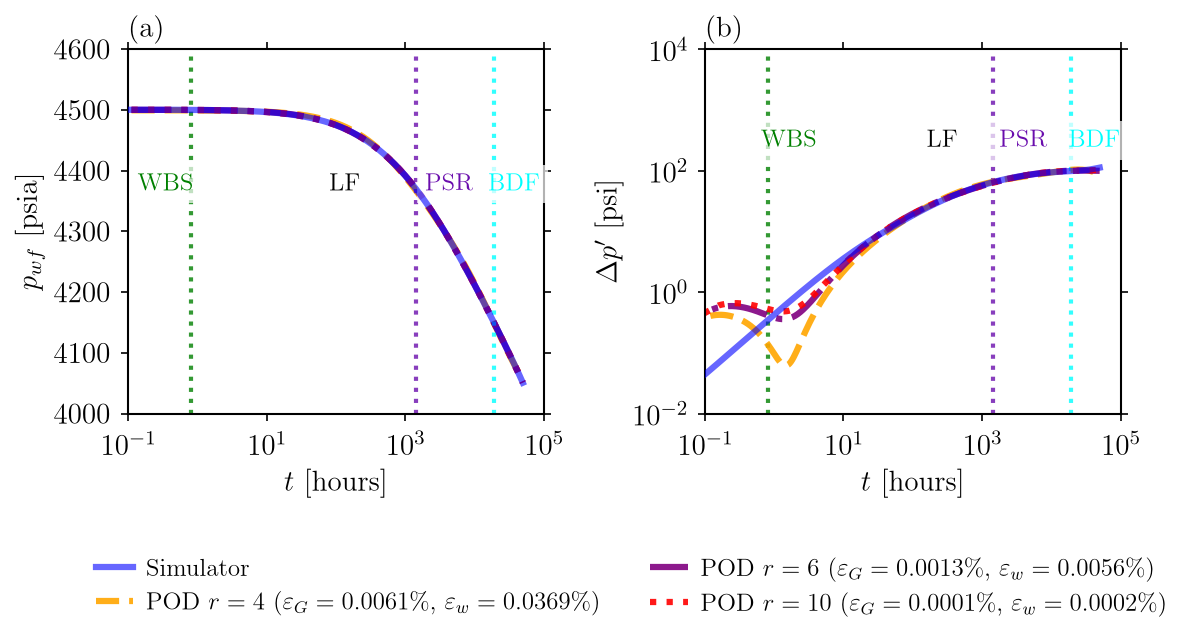

dp_correction : 0.0533 psia

   r           ε_G        ε_well     max|err| [psia]
────────────────────────────────────────────────────
   4       0.0061%       0.0369%              4.34
   6       0.0013%       0.0056%              0.68
  10       0.0001%       0.0002%              0.02


In [11]:
ranks  = [4, 6, 10]
colors = ['orange', 'purple', 'red']  # Updated to standard colors
styles = ['--', '-.', ':']

t_lo, t_hi = 0.001, 5e5
t_mask = (t>=t_lo)&(t<=t_hi)
lnt    = np.log(t)

t_lo_b   = 0.0001
t_mask_b = (t>=t_lo_b)&(t<=t_hi)

bhp_sim = bhp
dp_sim  = P['p_init_psia']-bhp_sim
dpr_sim = bourdet(np.clip(dp_sim,0,None),t,L=0.2)
vs_sim  = t_mask_b&(dp_sim>0.0)&(dpr_sim>0.00)
vs_sim_raw = t_mask_b & (dp_sim>0) & (dpr_sim>0)

rom_data={}
for r in ranks:
    X_r      = U[:,:r] @ np.diag(sv[:r]) @ Vt[:r,:] + X_mean
    bhp_r_wf = X_r[wc,:] - dp_correction
    dp_r     = P['p_init_psia'] - bhp_r_wf
    vf       = t_mask_b & (dp_r>0.0) & np.isfinite(dp_r)
    spl      = UnivariateSpline(lnt[vf], dp_r[vf], k=5, s=vf.sum()*0.3)
    dp_spl   = np.clip(spl(lnt), 0, None)
    dpr_spl  = np.clip(spl.derivative()(lnt), 0, None)
    vs_r     = t_mask_b & (dp_spl>0.0) & (dpr_spl>0.0)
    eg_r     = np.linalg.norm(X-X_r, 'fro') / np.linalg.norm(X, 'fro') * 100
    el       = (np.linalg.norm(bhp_sim[t_mask]-bhp_r_wf[t_mask]) /
                np.linalg.norm(bhp_sim[t_mask]) * 100)
    rom_data[r] = dict(bhp_wf=bhp_r_wf, dp_spl=dp_spl,
                       dpr_spl=dpr_spl, vs=vs_r, eg=eg_r, el=el)

log_lo = np.log10(t_lo)
log_range = np.log10(t_hi) - log_lo
def xpos(tv): return (np.log10(np.clip(tv, t_lo, t_hi)) - log_lo) / log_range

wbs_x = xpos(np.sqrt(t_lo * t_wbs))
lf_x  = xpos(np.sqrt(max(t_lo, t_wbs) * t_psr)) # Adjusted for t_lo = 1.0
psr_x = xpos(np.sqrt(t_psr * t_pss))
bdf_x = xpos(np.sqrt(t_pss * t_hi))

log_lo_b = np.log10(t_lo_b)
log_range_b = np.log10(t_hi) - log_lo_b
def xpos_b(tv): return (np.log10(np.clip(tv, t_lo_b, t_hi)) - log_lo_b) / log_range_b

wbs_xb = xpos_b(np.sqrt(t_lo_b * t_wbs))
lf_xb  = xpos_b(np.sqrt(t_wbs * t_psr))
psr_xb = xpos_b(np.sqrt(t_psr * t_pss))
bdf_xb = xpos_b(np.sqrt(t_pss * t_hi))

# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ── panel (a): BHP ────────────────────────────────────────────────────────
ax = axes[0]
ax.semilogx(t[t_mask], bhp_sim[t_mask],
            color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax.semilogx(t[t_mask], d['bhp_wf'][t_mask],
                color=col, lw=3.0, ls=ls, alpha=0.90,
                label=(rf'POD  $r={r}$  '
                       rf'($\varepsilon_G={d["eg"]:.4f}\%$, '
                       rf'$\varepsilon_{{w}}={d["el"]:.4f}\%$)'))

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax.axvline(t_psr, color=LF_C,    lw=2, ls=':', alpha=0.8)
ax.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

# Standardized Flow Regime labels
for xp, lbl, color_name in [(0.09, 'WBS', 'green'), (lf_x, 'LF', 'black'), (psr_x, 'PSR', LF_C), (bdf_x+0.01, 'BDF', 'cyan')]:
    ax.text(xp, 0.66, lbl, transform=ax.transAxes, fontsize=12,
            color=color_name, ha='center', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([0.1, 100000])
ax.set_ylim([4000, 4600])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ── panel (b): Bourdet derivative Δp' only ────────────────────────────────
ax2 = axes[1]
ax2.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax2.axvline(t_psr, color=LF_C,    lw=2, ls=':', alpha=0.8)
ax2.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

ax2.loglog(t[vs_sim], dpr_sim[vs_sim],
           color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax2.loglog(t[d['vs']], d['dpr_spl'][d['vs']],
               ls, color=col, lw=3.0, alpha=0.90, label=rf'POD  $r={r}$')

t_ref_r = np.logspace(np.log10(t_wbs*2), np.log10(t_psr*0.6), 100)

# Standardized Flow Regime labels (including WBS since it fits here)
for xp, lbl, color_name in [(wbs_xb, 'WBS', 'green'), (lf_xb, 'LF', 'black'), 
                            (psr_xb-0.03, 'PSR', LF_C), (bdf_xb+0.01, 'BDF', 'cyan')]:
    ax2.text(xp, 0.78, lbl, transform=ax2.transAxes, fontsize=12,
             color=color_name, ha='center', verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax2.set_title('(b)', loc='left', weight='normal')
ax2.set_xlabel('$t$ [hours]')
ax2.set_ylabel(r"$\Delta p'$ [psi]")
ax2.set_xlim([1e-1, 1e5])  # Adjusted to match t_lo_b
ax2.set_ylim([0.01, 10000])

ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())

# ── Figure-Level Legend ───────────────────────────────────────────────────
# Extract handles and labels from panel (a)
handles, labels = ax.get_legend_handles_labels()

# Place the legend at the bottom center of the figure, spanning 2 columns
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 0.0), 
           ncol=2, framealpha=0.0, fontsize=12)

# Adjust layout to match the requested framing
plt.tight_layout(rect=[0.01, 0.01, 1, 1.05])

#sf('fig11_fract_rom_comparison.pdf')
sf('ch5_11_pwf_dp_recon_case3.pdf')
plt.show()

# ── printed summary ────────────────────────────────────────────────────────
print(f'dp_correction : {dp_correction:.4f} psia')
print(f'\n{"r":>4}  {"ε_G":>12}  {"ε_well":>12}  {"max|err| [psia]":>18}')
print('─'*52)
for r in ranks:
    d = rom_data[r]
    mx = np.abs(bhp_sim[t_mask] - d['bhp_wf'][t_mask]).max()
    print(f'{r:4d}  {d["eg"]:>11.4f}%  {d["el"]:>11.4f}%  {mx:>16.2f}')

### Figure 12 — POD Reconstruction Error Over Time


---
## 9 · Ground Truth vs POD: Spatial Field Comparison

Four snapshots (WBS, LF, PSR, BDF) across ranks 4, 6, 10.


### Figure 14 — LF Snapshot Comparison by Rank


In [12]:
t_wbs_snap = t[m_wbs][len(t[m_wbs])//2]
t_lf_snap  = t[m_lf][len(t[m_lf])//2]
t_psr_snap = t[m_psr][len(t[m_psr])//2] if m_psr.any() else t_lf_snap
t_bdf_snap = t[m_bdf][len(t[m_bdf])//2]


  ch5_12_p_field_recon_case3.pdf


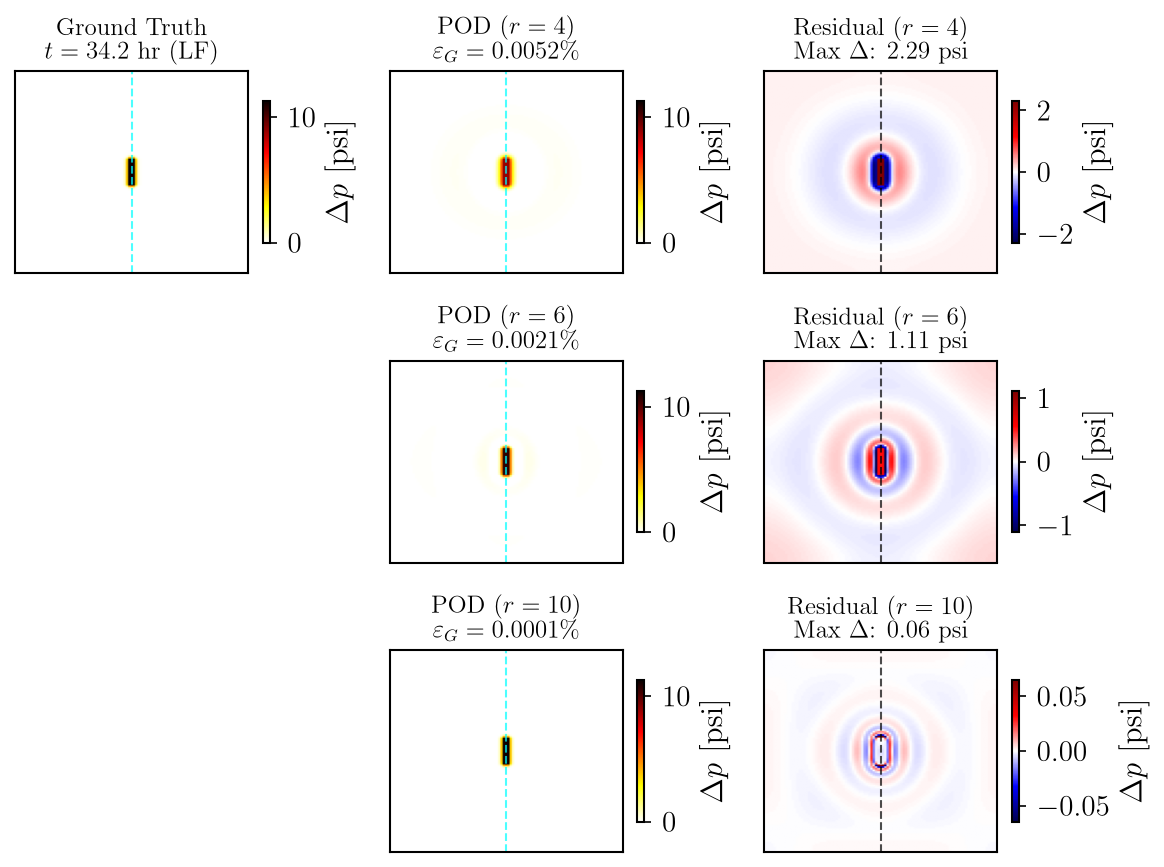

In [13]:
n_ranks = len(ranks)

# Matching the standardized matrix figure size
fig, axes = plt.subplots(n_ranks, 3, figsize=(8, 6))

ki   = int(np.argmin(np.abs(t - t_lf_snap)))
F_gt = dX[:, ki].reshape(ny, nx)
vm   = max(F_gt.max(), 0.1)

for ri, r in enumerate(ranks):
    X_r      = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    dX_r     = (P['p_init_psia'] - X_r)[:, ki].reshape(ny, nx)
    diff     = F_gt - dX_r
    eps_step = np.linalg.norm(X[:, ki] - X_r[:, ki]) / np.linalg.norm(X[:, ki]) * 100
    vd       = max(np.abs(diff).max(), 0.01)

    # ── Column 0: Ground Truth (first row only) ───────────────────────────
    ax_gt = axes[ri, 0]
    if ri == 0:
        im1 = ax_gt.imshow(F_gt, origin='lower', cmap='hot_r', vmin=0, vmax=vm, aspect='auto')
        ax_gt.set_title(rf'Ground Truth' + '\n' + rf'$t={t[ki]:.1f}$ hr (LF)', 
                        fontweight='normal', fontsize=12)
        ax_gt.axvline(frac_col_py, color='cyan', lw=1.0, ls='--', alpha=0.7)
        # ax_gt.plot(frac_col_py, ny//2, 'w+', ms=7, mew=1.5)
        fig.colorbar(im1, ax=ax_gt, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)
    else:
        ax_gt.axis('off')

    # ── Column 1: POD Reconstruction ──────────────────────────────────────
    ax_pod = axes[ri, 1]
    im2 = ax_pod.imshow(dX_r, origin='lower', cmap='hot_r', vmin=0, vmax=vm, aspect='auto')
    ax_pod.set_title(rf'POD ($r={r}$)' + '\n' + rf'$\varepsilon_G={eps_step:.4f}\%$', 
                     fontweight='normal', fontsize=12)
    ax_pod.axvline(frac_col_py, color='cyan', lw=1.0, ls='--', alpha=0.7)
    # ax_pod.plot(frac_col_py, ny//2, 'w+', ms=7, mew=1.5)
    fig.colorbar(im2, ax=ax_pod, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)

    # ── Column 2: Residual ─────────────────────────────────────────────────
    ax_res = axes[ri, 2]
    im3 = ax_res.imshow(diff, origin='lower', cmap='seismic', vmin=-vd, vmax=vd, aspect='auto')
    ax_res.set_title(rf'Residual ($r={r}$)' + '\n' + rf'Max $\Delta$: {vd:.2f} psi', 
                     fontweight='normal', fontsize=12)
    ax_res.axvline(frac_col_py, color='k', lw=1.0, ls='--', alpha=0.7)
    # ax_res.plot(frac_col_py, ny//2, 'k+', ms=7, mew=1.5)
    fig.colorbar(im3, ax=ax_res, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)

    for ax_obj in [ax_gt, ax_pod, ax_res]:
        if ax_obj.axison:
            ax_obj.set_xticks([])
            ax_obj.set_yticks([])

plt.tight_layout()
#sf('fig14_LF_reconstruction_matrix.pdf')
sf('ch5_12_p_field_recon_case3.pdf')
plt.show()

---
## 10 · Reservoir Characterisation from POD

$m_{LF} \to x_f\sqrt{k_m}$; $\Delta p'_{PSR} \to k_m h \to k_m \to x_f$.


In [14]:
def characterise_frac(dp_arr,t_arr,lf_m,psr_m,vs_m,label):
    if lf_m.sum()>3:
        cf=np.polyfit(np.sqrt(t_arr[lf_m]),dp_arr[lf_m],1)
        m_lf_val=cf[0]
    else:
        m_lf_val=np.nan
    xf_sqrt_k=(4.064*q*Bo*mu/(m_lf_val*h_ft*np.sqrt(phi_*mu*ct))
               if np.isfinite(m_lf_val) else np.nan)
    dpr_arr=bourdet(np.clip(dp_arr,0,None),t_arr,L=0.2)
    flat_val=(np.median(dpr_arr[psr_m&vs_m&(dpr_arr>0)])
              if psr_m.any() else np.nan)
    kh_b=70.6*q*mu*Bo/flat_val if np.isfinite(flat_val) else np.nan
    k_b=kh_b/h_ft if np.isfinite(kh_b) else np.nan
    xf_val=(xf_sqrt_k/np.sqrt(k_b)
            if (np.isfinite(xf_sqrt_k) and np.isfinite(k_b) and k_b>0) else np.nan)
    return dict(label=label,m_lf=m_lf_val,xf_sqrt_k=xf_sqrt_k,
                flat_psr=flat_val,kh_b=kh_b,k_b=k_b,xf_est=xf_val)

res_sim=characterise_frac(dp,t,m_lf,m_psr,vs,'Simulator (GT)')
results=[res_sim]
for r in ranks:
    X_r=U[:,:r]@np.diag(sv[:r])@Vt[:r,:]+X_mean
    bhp_r_wf=X_r[wc,:]-dp_correction
    dp_r=P['p_init_psia']-bhp_r_wf
    dpr_r=bourdet(np.clip(dp_r,0,None),t,L=0.2)
    vs_r=m_lf&(dpr_r>1e-2)&(dp_r>1e-2)
    vs_r_psr=m_psr&(dpr_r>1e-2)&(dp_r>1e-2)
    results.append(characterise_frac(dp_r,t,m_lf,m_psr,
                                     vs_r|vs_r_psr,f'POD r={r}'))

W=16
print('='*95)
print(' RESERVOIR CHARACTERISATION — Case 3 (Hydraulically Fractured)')
print('='*95)
print(f'  True: k_m={k_m:.0f} mD  kh={kh:.0f} mD-ft  xf={xf_ft:.0f} ft  S={P["S_skin"]:.0f}')
print()
hdr=f'{"":20s} {"True":>{W}} '+''.join([f'{r["label"]:>{W}} ' for r in results])
print(hdr); print('-'*95)

def row(lbl,key,fmt,ref):
    line=f'{lbl:<20s} {ref:>{W}{fmt}} '
    for res in results:
        v=res[key]
        line+=f'{v:>{W}{fmt}} ' if np.isfinite(v) else f'{"—":>{W}} '
    print(line)

def row_err(lbl,key,ref):
    line=f'{lbl:<20s} {"—":>{W}} '
    for res in results:
        v=res[key]
        if np.isfinite(v) and ref!=0:
            line+=f'{(v-ref)/abs(ref)*100:>{W}.2f} '
        else:
            line+=f'{"—":>{W}} '
    print(line)

print('\n  -- LINEAR FLOW --')
row('m_LF [psi/hr^0.5]',  'm_lf',    '.4f', m_LF_theory)
row('xf*sqrt(k) [ft mD^0.5]','xf_sqrt_k','.1f',xf_ft*np.sqrt(k_m))
row_err('  m_LF error [%]','m_lf',m_LF_theory)
print('\n  -- PSR BOURDET FLAT --')
row('Dp_flat_PSR [psi]',  'flat_psr','.4f', dp_flat_psr)
row('kh_m [mD-ft]',       'kh_b',   '.2f', kh)
row('k_m [mD]',           'k_b',    '.3f', k_m)
row_err('  kh error [%]', 'kh_b',   kh)
row_err('  k_m error [%]','k_b',    k_m)
print('\n  -- FRACTURE HALF-LENGTH --')
row('xf estimate [ft]',   'xf_est', '.1f', xf_ft)
row_err('  xf error [%]', 'xf_est', xf_ft)
print('='*95)

 RESERVOIR CHARACTERISATION — Case 3 (Hydraulically Fractured)
  True: k_m=5 mD  kh=750 mD-ft  xf=1312 ft  S=0

                                 True   Simulator (GT)          ROM r=4          ROM r=6         ROM r=10 
-----------------------------------------------------------------------------------------------

  -- LINEAR FLOW --
m_LF [psi/hr^0.5]              6.3320           3.5817           3.6134           3.5896           3.5818 
xf*sqrt(k) [ft mD^0.5]           2934.5           5187.8           5142.3           5176.4           5187.6 
  m_LF error [%]                    —           -43.43           -42.93           -43.31           -43.43 

  -- PSR BOURDET FLAT --
Dp_flat_PSR [psi]            103.9232          86.4931          82.1261          86.4372          86.4857 
kh_m [mD-ft]                   750.00           901.14           949.06           901.72           901.22 
k_m [mD]                        5.000            6.008            6.327            6.011            6

---
## 11 · Summary

In [15]:
import json as js
summary=dict(
    case='case3_fractured',
    k_m=float(k_m),k_f=float(k_f),xf_ft=float(xf_ft),
    m_LF_theory=float(m_LF_theory),m_LF_sim=float(m_LF_sim),
    dp_flat_psr_theory=float(dp_flat_psr),dp_flat_psr_sim=float(flat_psr_sim),
    kh_true=float(kh),kh_psr_est=float(kh_psr_est),
    xf_est=float(results[0]['xf_est']),
    r_sel=int(r_sel),r999=int(r999),
    sigma1=float(sv[0]),sigma2_ratio=float(sn[1]),
 
    t_wbs_hr=float(t_wbs),t_psr_hr=float(t_psr),t_pss_hr=float(t_pss),
)
out_file=PROJECT/'data'/'processed'/'case3_summary.json'
with open(out_file,'w') as f: js.dump(summary,f,indent=2)
print('── SUMMARY ──────────────────────────────')
for k_,v_ in summary.items(): print(f'  {k_:<30}: {v_}')
print(f'Saved: {out_file}')

── SUMMARY ──────────────────────────────
  case                          : case3_fractured
  k_m                           : 5.0
  k_f                           : 100000.0
  xf_ft                         : 1312.336
  m_LF_theory                   : 6.331993685
  m_LF_sim                      : 3.5817094987444227
  dp_flat_psr_theory            : 103.9231967
  dp_flat_psr_sim               : 86.49313746645846
  kh_true                       : 750.000024
  kh_psr_est                    : 901.1397005944615
  xf_est                        : 2116.5558554322474
  r_sel                         : 3
  r999                          : 3
  sigma1                        : 48681.471859513855
  sigma2_ratio                  : 0.2329263338834616
  t_wbs_hr                      : 0.8159999739
  t_psr_hr                      : 1428.111207
  t_pss_hr                      : 19017.81615
Saved: ..\data\processed\case3_summary.json
